# ENCS5433 — Parts 6 & 7: Speech Synthesis
**Birzeit University — Spring 2026**
- **Part 6:** Concatenative Synthesis → synthesize "light" from "life" + "night"
- **Part 7:** Source–Filter Vowel Synthesis → /a/, /u/, /ə/ from pulse-train + IIR filter


## Setup

In [1]:
!pip install -q librosa soundfile scipy numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as sig
import soundfile as sf
import librosa
import os
from IPython.display import Audio, display

os.makedirs('/content/figures', exist_ok=True)
os.makedirs('/content/synthesis', exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print("✅ Ready")


✅ Ready


## Upload your WAV files
Upload `life.wav` and `night.wav` (recorded at 16 kHz mono).  
Run the cell, click **Choose Files**, select both.


In [2]:
from google.colab import files
uploaded = files.upload()
for name, data in uploaded.items():
    path = f'/content/{name}'
    with open(path, 'wb') as f:
        f.write(data)
    print(f"✅ Uploaded: {path}")


Saving life.wav to life.wav
Saving night.wav to night.wav
✅ Uploaded: /content/life.wav
✅ Uploaded: /content/night.wav


## Inspect recordings — find your timestamps
Run this on each file. Look at the waveform and spectrogram to identify where each phoneme starts/ends, then fill in the timestamps in the Part 6 cell below.


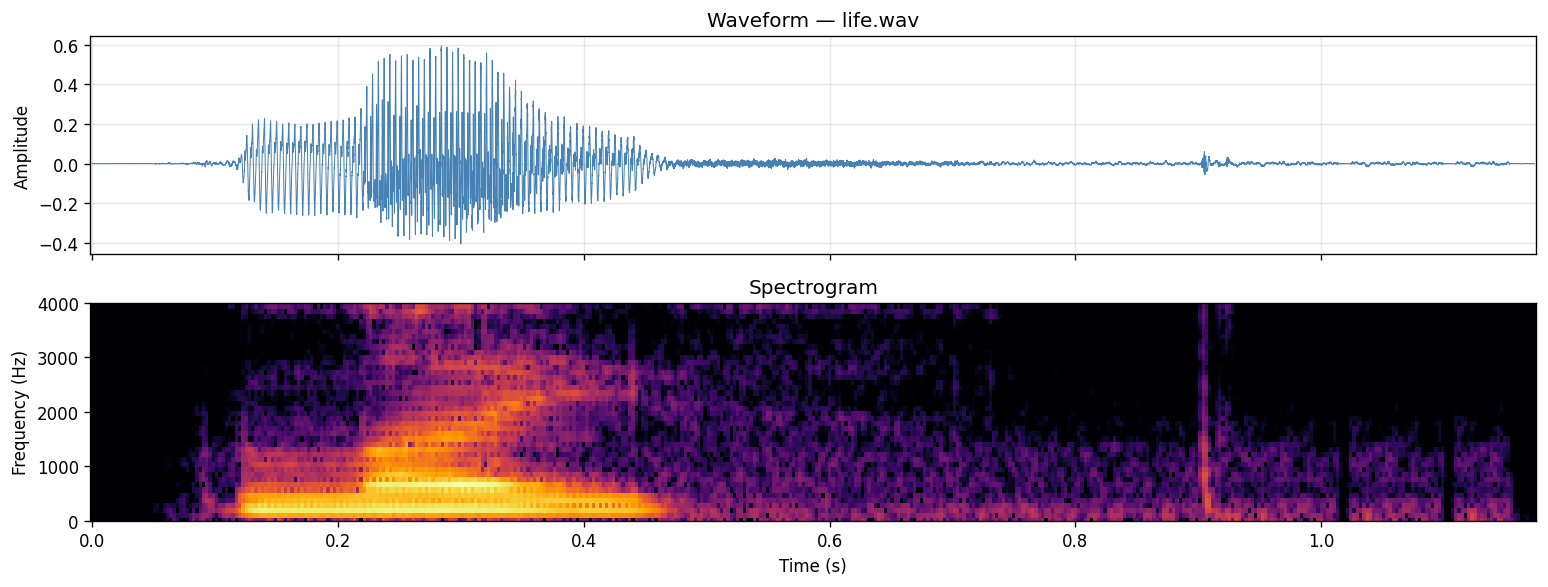

  Duration: 1.173 s  |  SR: 48000 Hz


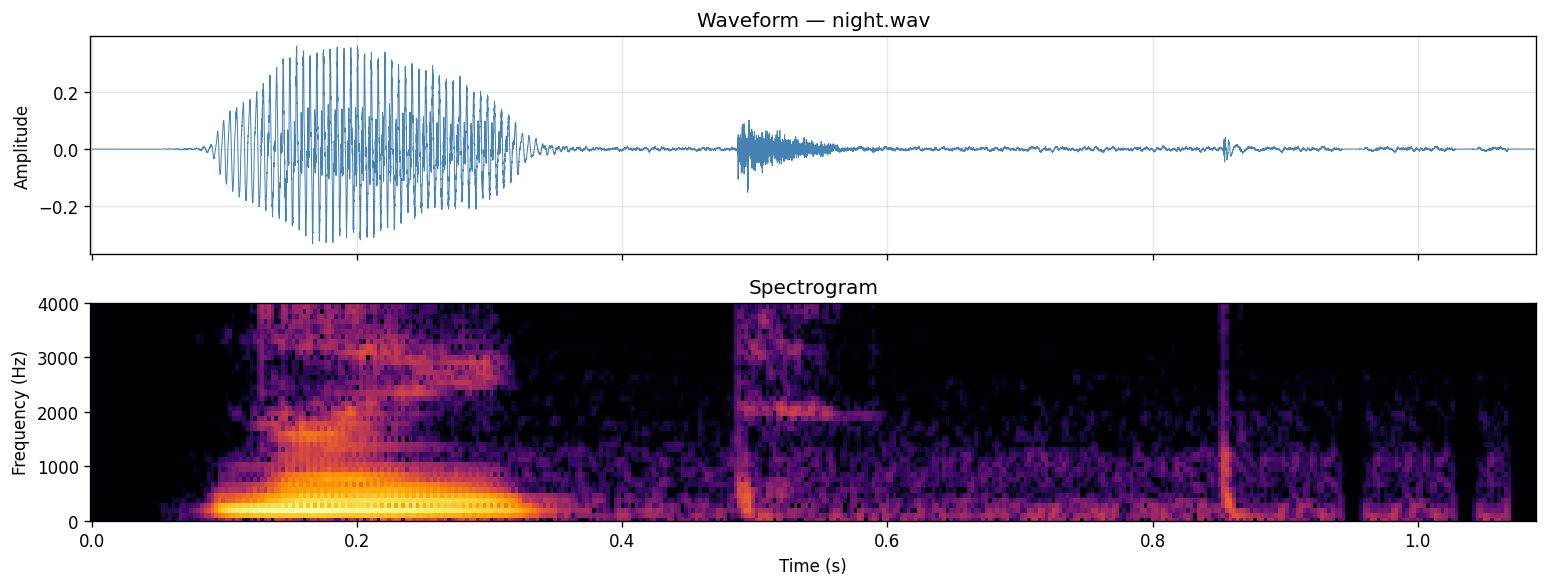

  Duration: 1.088 s  |  SR: 48000 Hz


In [3]:
def inspect(wav_path):
    if not os.path.exists(wav_path):
        print(f"⚠️ Not found: {wav_path}"); return
    y, sr = librosa.load(wav_path, sr=None, mono=True)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(y, n_fft=512)), ref=np.max)
    t_wav  = np.arange(len(y)) / sr
    t_spec = librosa.frames_to_time(np.arange(D.shape[1]), sr=sr, hop_length=128)
    freqs  = librosa.fft_frequencies(sr=sr, n_fft=512)

    fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
    axes[0].plot(t_wav, y, color='steelblue', linewidth=0.6)
    axes[0].set_ylabel("Amplitude")
    axes[0].set_title(f"Waveform — {os.path.basename(wav_path)}")
    axes[0].grid(True, alpha=0.3)
    axes[1].pcolormesh(t_spec, freqs, D, shading='auto', cmap='inferno', vmin=-60)
    axes[1].set_ylim(0, 4000)
    axes[1].set_ylabel("Frequency (Hz)")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_title("Spectrogram")
    plt.tight_layout(); plt.show()
    print(f"  Duration: {len(y)/sr:.3f} s  |  SR: {sr} Hz")
    display(Audio(wav_path))

inspect('/content/life.wav')
inspect('/content/night.wav')


---
## Part 6 — Concatenative Speech Synthesis [15 Marks]

**Target:** "light" = /l/ + /aɪ/ + /t/

| Phoneme | Source | Where |
|---------|--------|-------|
| /l/  | `life.wav`  | onset — before the vowel |
| /aɪ/ | `night.wav` | vowel nucleus |
| /t/  | `night.wav` | final burst/closure |

**After inspecting the recordings above, fill in the 6 timestamps below.**


In [6]:
# ── SET THESE after inspecting the waveforms above ──────────────────────────
LIFE_PATH  = '/content/life.wav'
NIGHT_PATH = '/content/night.wav'

TARGET_SR = 16000

L_start,  L_end  = 0.00, 0.12   # /l/  from "life"   ← EDIT
# ── AUTO-DETECT vowel onset in night.wav (skips the /n/) ───────────────────
def detect_vowel_onset(path, sr=TARGET_SR):
    """Find where the vowel starts in night.wav by detecting the 2nd onset.
    The /n/ in night is a nasal — voiced but spectrally different from the vowel.
    librosa onset_detect picks up the energy surge when /n/ transitions to /aɪ/.
    """
    y, _ = librosa.load(path, sr=sr, mono=True)
    # onset_detect finds spectral flux peaks — the /n/→/aɪ/ transition is one
    onsets = librosa.onset.onset_detect(y=y, sr=sr, units="time",
                                        hop_length=128, backtrack=True)
    print(f"  Detected onsets in night.wav: {[f'{t:.3f}s' for t in onsets]}")
    # We want the SECOND onset (first = /n/ attack, second = /aɪ/ vowel burst)
    if len(onsets) >= 2:
        vowel_t = onsets[1]
    elif len(onsets) == 1:
        vowel_t = onsets[0] + 0.05   # fallback: shift 50 ms past only onset
    else:
        vowel_t = 0.15               # last resort
    return max(0.0, vowel_t - 0.01)  # back off 10 ms to catch vowel onset cleanly

AI_start_auto = detect_vowel_onset(NIGHT_PATH)
print(f"🔍 Auto-detected /aɪ/ vowel onset in night.wav: {AI_start_auto:.3f} s")
AI_start = AI_start_auto
AI_end   = AI_start + 0.28   # ~280 ms of vowel; adjust if needed
print(f"   AI_start={AI_start:.3f}  AI_end={AI_end:.3f}")
# Update T_start to begin right after vowel
T_start = AI_end
T_end   = T_start + 0.15
print(f"   T_start={T_start:.3f}   T_end={T_end:.3f}")
# ─────────────────────────────────────────────────────────────────────────────
# (original static values kept as fallback reference — edit if auto fails)
# AI_start, AI_end = 0.15, 0.42   # /aɪ/ from "night"
# T_start/T_end are now set automatically above after AI_end
# ─────────────────────────────────────────────────────────────────────────────

def extract(path, t0, t1, sr=TARGET_SR):
    y, orig_sr = librosa.load(path, sr=sr, mono=True)
    return y[int(t0*sr) : int(t1*sr)]

def normalize(x):
    return x / (np.max(np.abs(x)) + 1e-8)

def crossfade(a, b, sr, ms=8):   # 8 ms — tight enough to preserve short consonants like /l/
    n = min(int(ms * sr / 1000), len(a), len(b))
    fade_out = np.linspace(1, 0, n)
    fade_in  = np.linspace(0, 1, n)
    return np.concatenate([a[:-n],
                           a[-n:] * fade_out + b[:n] * fade_in,
                           b[n:]])

# ── AUTO-DETECT onsets (fixes silent lead-in) ───────────────────────────────
# Instead of guessing L_start, we find where energy actually begins in life.wav
def detect_onset(path, sr=TARGET_SR, threshold_db=-40):
    """Return the time (s) where RMS energy first crosses threshold_db."""
    y, _ = librosa.load(path, sr=sr, mono=True)
    frame_len = 512
    hop       = 128
    rms = librosa.feature.rms(y=y, frame_length=frame_len, hop_length=hop)[0]
    rms_db = librosa.amplitude_to_db(rms, ref=np.max)
    active = np.where(rms_db > threshold_db)[0]
    if len(active) == 0:
        print("⚠️  No onset found — recording may be too quiet. Lower threshold_db.")
        return 0.0
    onset_sample = active[0] * hop
    onset_time   = onset_sample / sr
    return max(0.0, onset_time - 0.01)   # back off 10 ms to catch the transient

L_start_auto = detect_onset(LIFE_PATH)
print(f"🔍 Auto-detected /l/ onset in life.wav: {L_start_auto:.3f} s")
print(f"   (was hardcoded to {L_start:.3f} s — overriding now)")
L_start = L_start_auto
L_end   = L_start + 0.12   # /l/ is ~80-120 ms; adjust if needed
print(f"   L_start={L_start:.3f}  L_end={L_end:.3f}")
# ─────────────────────────────────────────────────────────────────────────────

seg_l  = normalize(extract(LIFE_PATH,  L_start,  L_end))
seg_ai = normalize(extract(NIGHT_PATH, AI_start, AI_end))
seg_t  = normalize(extract(NIGHT_PATH, T_start,  T_end))

# Raw concatenation (no smoothing)
synth_raw = normalize(np.concatenate([seg_l, seg_ai, seg_t]))

# Crossfaded concatenation
synth_cf  = normalize(crossfade(crossfade(seg_l, seg_ai, TARGET_SR), seg_t, TARGET_SR))

sf.write('/content/synthesis/light_raw.wav',        synth_raw, TARGET_SR)
sf.write('/content/synthesis/light_crossfaded.wav', synth_cf,  TARGET_SR)
print("✅ Saved: light_raw.wav  |  light_crossfaded.wav")

# ── Verify each segment individually ──────────────────────────────────────────
print("\n🔍 Listen to each segment BEFORE the full result.")
print("   If Segment 2 sounds like it starts with /n/, increase AI_start and re-run.")
print("\n▶ Segment 1 — /l/ from life.wav (should be the 'l' consonant only):")
display(Audio(seg_l, rate=TARGET_SR))
print(f"   Duration: {len(seg_l)/TARGET_SR*1000:.0f} ms")
print("\n▶ Segment 2 — /aɪ/ from night.wav (should be a pure VOWEL, NO /n/ at the start):")
display(Audio(seg_ai, rate=TARGET_SR))
print(f"   Duration: {len(seg_ai)/TARGET_SR*1000:.0f} ms")
print("\n▶ Segment 3 — /t/ from night.wav (short closure/burst at the end):")
display(Audio(seg_t, rate=TARGET_SR))
print(f"   Duration: {len(seg_t)/TARGET_SR*1000:.0f} ms")

# ── Verify each segment individually BEFORE listening to the result ──
print("\n🔍 Check each segment — if any sounds wrong, adjust the timestamps above and re-run.")
print("\n▶ Segment 1 — /l/ from life.wav (should sound like the 'l' consonant only):")
display(Audio(seg_l, rate=TARGET_SR))
print(f"   Duration: {len(seg_l)/TARGET_SR*1000:.0f} ms")
print("\n▶ Segment 2 — /aɪ/ from night.wav (should be a PURE VOWEL, no /n/ at the start):")
display(Audio(seg_ai, rate=TARGET_SR))
print(f"   Duration: {len(seg_ai)/TARGET_SR*1000:.0f} ms")
print("\n▶ Segment 3 — /t/ from night.wav (short burst/closure):")
display(Audio(seg_t, rate=TARGET_SR))
print(f"   Duration: {len(seg_t)/TARGET_SR*1000:.0f} ms")

  Detected onsets in night.wav: ['0.064s', '0.120s', '0.488s', '0.832s', '1.000s']
🔍 Auto-detected /aɪ/ vowel onset in night.wav: 0.110 s
   AI_start=0.110  AI_end=0.390
   T_start=0.390   T_end=0.540
🔍 Auto-detected /l/ onset in life.wav: 0.070 s
   (was hardcoded to 0.000 s — overriding now)
   L_start=0.070  L_end=0.190
✅ Saved: light_raw.wav  |  light_crossfaded.wav

🔍 Listen to each segment BEFORE the full result.
   If Segment 2 sounds like it starts with /n/, increase AI_start and re-run.

▶ Segment 1 — /l/ from life.wav (should be the 'l' consonant only):


   Duration: 120 ms

▶ Segment 2 — /aɪ/ from night.wav (should be a pure VOWEL, NO /n/ at the start):


   Duration: 280 ms

▶ Segment 3 — /t/ from night.wav (short closure/burst at the end):


   Duration: 150 ms

🔍 Check each segment — if any sounds wrong, adjust the timestamps above and re-run.

▶ Segment 1 — /l/ from life.wav (should sound like the 'l' consonant only):


   Duration: 120 ms

▶ Segment 2 — /aɪ/ from night.wav (should be a PURE VOWEL, no /n/ at the start):


   Duration: 280 ms

▶ Segment 3 — /t/ from night.wav (short burst/closure):


   Duration: 150 ms


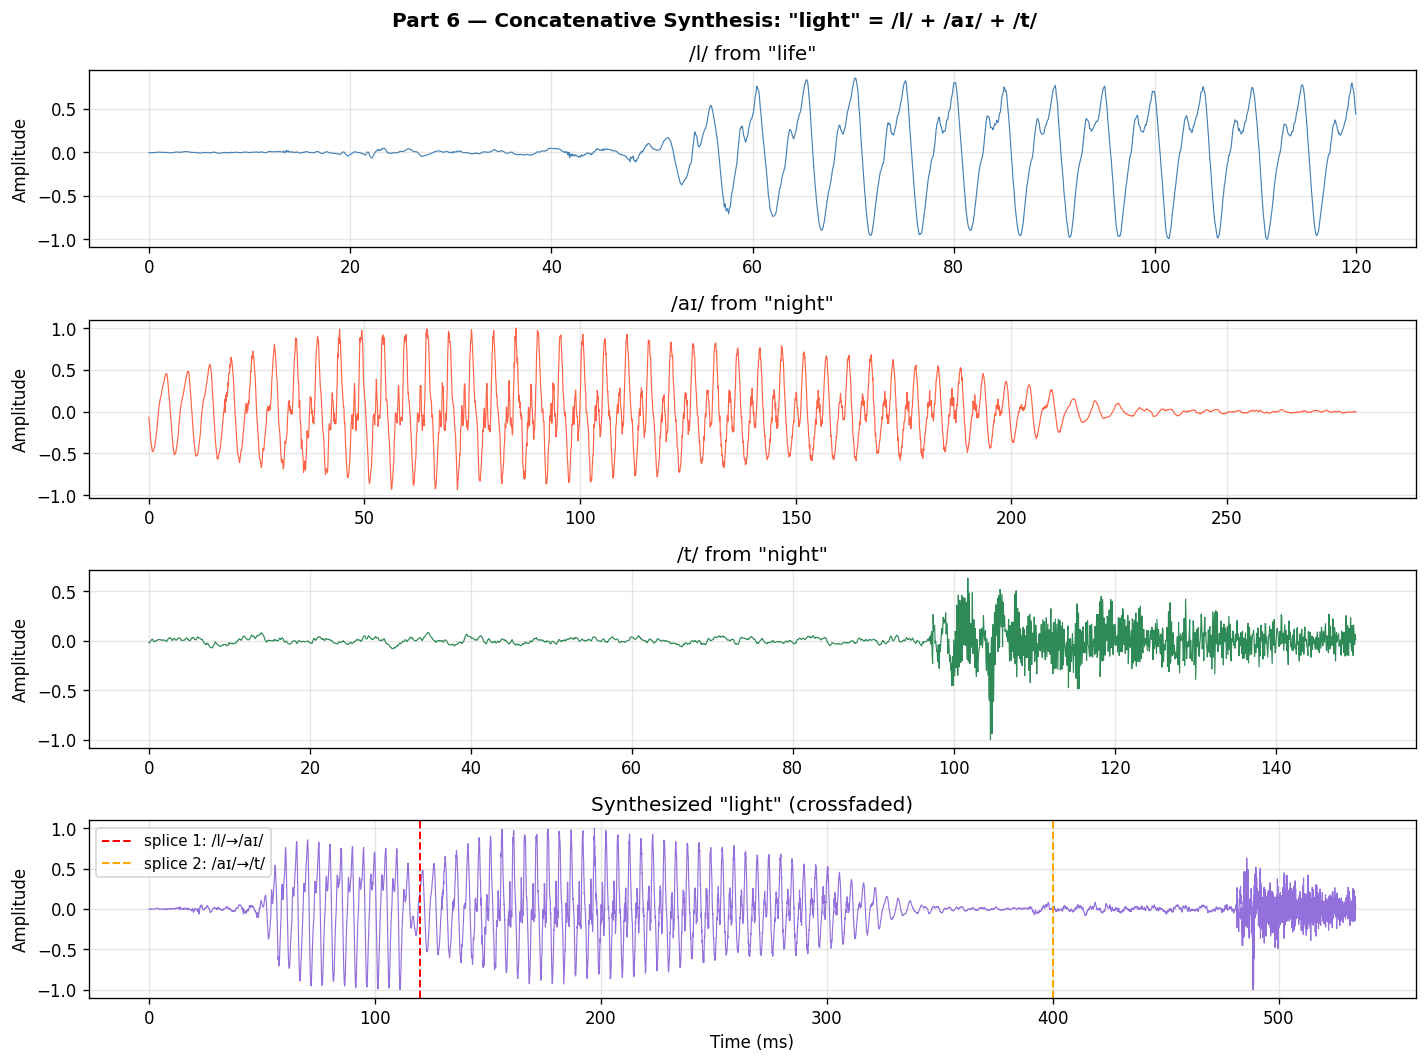


▶ Raw (no smoothing):



▶ Crossfaded (smooth transitions):


In [7]:
# ── Part 6: Plot ─────────────────────────────────────────────────────────────
sr = TARGET_SR
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=False)
fig.suptitle('Part 6 — Concatenative Synthesis: "light" = /l/ + /aɪ/ + /t/',
             fontsize=12, fontweight='bold')

segs   = [seg_l,  seg_ai,  seg_t,      synth_cf]
labels = ['/l/ from "life"', '/aɪ/ from "night"', '/t/ from "night"',
          'Synthesized "light" (crossfaded)']
colors = ['steelblue', 'tomato', 'seagreen', 'mediumpurple']

for ax, seg, lbl, col in zip(axes, segs, labels, colors):
    t = np.arange(len(seg)) / sr * 1000
    ax.plot(t, seg, color=col, linewidth=0.7)
    ax.set_ylabel("Amplitude")
    ax.set_title(lbl)
    ax.grid(True, alpha=0.3)

# Mark splice points on bottom panel
l_ms  = len(seg_l)  / sr * 1000
ai_ms = (len(seg_l) + len(seg_ai)) / sr * 1000
axes[3].axvline(l_ms,  color='red',    linestyle='--', linewidth=1.2, label='splice 1: /l/→/aɪ/')
axes[3].axvline(ai_ms, color='orange', linestyle='--', linewidth=1.2, label='splice 2: /aɪ/→/t/')
axes[3].legend(fontsize=9)
axes[3].set_xlabel("Time (ms)")

plt.tight_layout()
plt.savefig('/content/figures/part6_concatenative_synthesis.png', bbox_inches='tight')
plt.show()

print("\n▶ Raw (no smoothing):")
display(Audio('/content/synthesis/light_raw.wav'))
print("\n▶ Crossfaded (smooth transitions):")
display(Audio('/content/synthesis/light_crossfaded.wav'))


---
## Part 7 — Source–Filter Vowel Synthesis [15 Marks]

**Method:** Pulse-train excitation → cascade of 2nd-order IIR resonators (formant filters) → radiation model (high-pass)

| Vowel | F1 | F2 | F3 | F0 |
|-------|----|----|----|----|
| /a/   | 800 Hz | 1200 Hz | 2500 Hz | 120 Hz |
| /u/   | 300 Hz | 800 Hz  | 2200 Hz | 110 Hz |
| /ə/   | 500 Hz | 1500 Hz | 2500 Hz | 120 Hz |

No recordings needed — fully parametric synthesis.


In [8]:
def make_formant_sos(fs, formants_bw):
    """Build cascade SOS filter from list of (frequency, bandwidth) pairs."""
    sections = []
    for F, B in formants_bw:
        T     = 1.0 / fs
        r     = np.exp(-np.pi * B * T)
        theta = 2 * np.pi * F * T
        a1    = -2 * r * np.cos(theta)
        a2    = r ** 2
        gain  = 1 - r**2          # normalize resonance peak
        sections.append([gain, 0.0, 0.0, 1.0, a1, a2])
    return np.array(sections)


def synthesize_vowel(label, F1, F2, F3, f0=120, duration=1.0, fs=16000,
                     B1=80, B2=100, B3=120):
    """
    Synthesize a vowel using:
      1. Periodic pulse-train source (glottal excitation)
      2. Cascade formant filter (vocal tract)
      3. High-pass radiation filter
    """
    n   = int(duration * fs)
    T0  = int(fs / f0)            # samples per pitch period

    # ── 1. Pulse-train source ──
    source = np.zeros(n)
    source[::T0] = 1.0
    # Smooth glottal pulses with a mild low-pass
    b_g, a_g = sig.butter(1, 800 / (fs/2), btype='low')
    source   = sig.lfilter(b_g, a_g, source)

    # ── 2. Vocal-tract filter (cascade formants) ──
    sos    = make_formant_sos(fs, [(F1,B1), (F2,B2), (F3,B3)])
    speech = sig.sosfilt(sos, source)

    # ── 3. Radiation model (differentiation ≈ high-pass) ──
    b_r, a_r = sig.butter(1, 50 / (fs/2), btype='high')
    speech   = sig.lfilter(b_r, a_r, speech)

    # Normalize + fade in/out (20 ms)
    speech  /= np.max(np.abs(speech)) + 1e-8
    fade     = int(0.02 * fs)
    speech[:fade]  *= np.linspace(0, 1, fade)
    speech[-fade:] *= np.linspace(1, 0, fade)

    path = f'/content/synthesis/vowel_{label}_synth.wav'
    sf.write(path, speech, fs)
    print(f"✅ Synthesized /{label}/  →  {path}")
    return speech, fs


# ── Synthesize all three vowels ──────────────────────────────────────────────
vowels = {
    'a':     dict(F1=800,  F2=1200, F3=2500, f0=120),
    'u':     dict(F1=300,  F2=800,  F3=2200, f0=110),
    'schwa': dict(F1=500,  F2=1500, F3=2500, f0=120),
}
ipa = {'a': '/a/', 'u': '/u/', 'schwa': '/ə/'}

results = {}
for label, params in vowels.items():
    speech, fs = synthesize_vowel(label, **params)
    results[label] = (speech, fs)


✅ Synthesized /a/  →  /content/synthesis/vowel_a_synth.wav
✅ Synthesized /u/  →  /content/synthesis/vowel_u_synth.wav
✅ Synthesized /schwa/  →  /content/synthesis/vowel_schwa_synth.wav


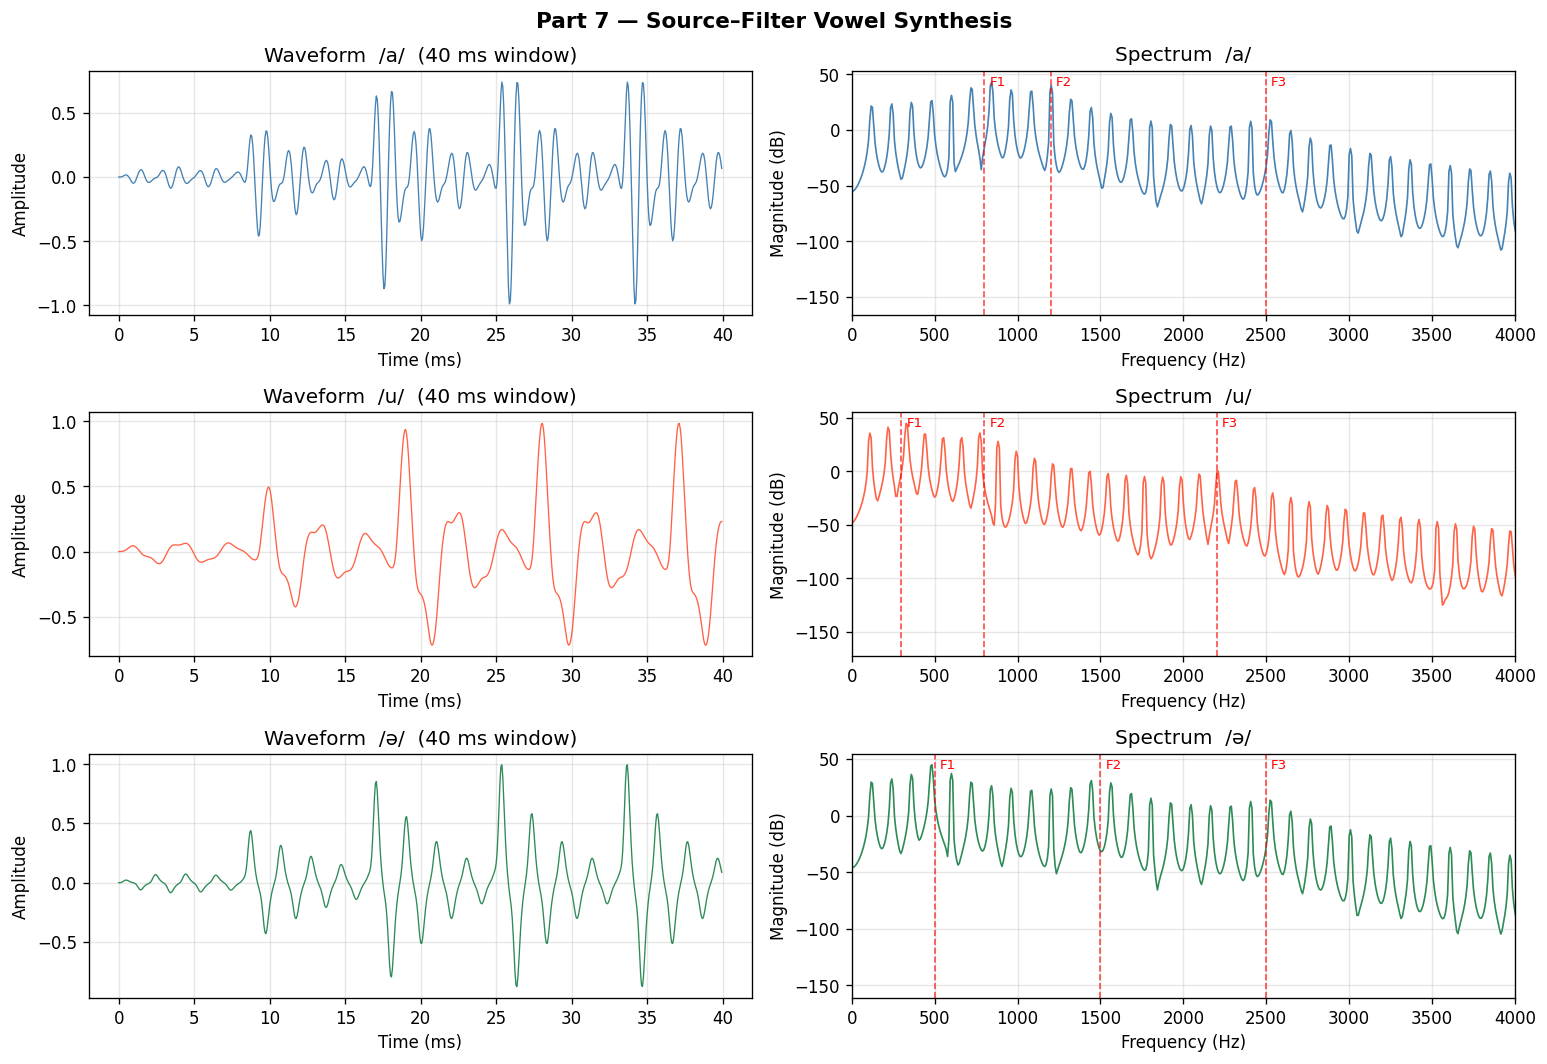


▶ Synthesized /a/



▶ Synthesized /u/



▶ Synthesized /ə/


In [9]:
# ── Part 7: Waveform + Spectrum for each vowel ───────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(13, 9))
fig.suptitle("Part 7 — Source–Filter Vowel Synthesis", fontsize=13, fontweight='bold')
colors = ['steelblue', 'tomato', 'seagreen']

for idx, (label, (speech, fs)) in enumerate(results.items()):
    params = vowels[label]
    t = np.arange(len(speech)) / fs

    # Waveform — show 40 ms
    show = int(0.04 * fs)
    axes[idx, 0].plot(t[:show]*1000, speech[:show], color=colors[idx], linewidth=0.8)
    axes[idx, 0].set_title(f"Waveform  {ipa[label]}  (40 ms window)")
    axes[idx, 0].set_xlabel("Time (ms)")
    axes[idx, 0].set_ylabel("Amplitude")
    axes[idx, 0].grid(True, alpha=0.3)

    # Spectrum
    N      = 2048
    center = len(speech) // 2
    frame  = speech[center : center+N] * np.hanning(N)
    freqs  = np.fft.rfftfreq(N, d=1/fs)
    mag_db = 20 * np.log10(np.abs(np.fft.rfft(frame)) + 1e-10)
    axes[idx, 1].plot(freqs, mag_db, color=colors[idx], linewidth=1.0)
    axes[idx, 1].set_xlim(0, 4000)
    axes[idx, 1].set_xlabel("Frequency (Hz)")
    axes[idx, 1].set_ylabel("Magnitude (dB)")
    axes[idx, 1].set_title(f"Spectrum  {ipa[label]}")
    axes[idx, 1].grid(True, alpha=0.3)

    # Mark formant positions
    top = mag_db[freqs < 4000].max()
    for F, lbl in zip([params['F1'], params['F2'], params['F3']], ['F1','F2','F3']):
        axes[idx, 1].axvline(F, color='red', linestyle='--', alpha=0.7, linewidth=1)
        axes[idx, 1].text(F+30, top - 3, lbl, color='red', fontsize=8)

plt.tight_layout()
plt.savefig('/content/figures/part7_vowel_synthesis.png', bbox_inches='tight')
plt.show()

for label, (speech, fs) in results.items():
    print(f"\n▶ Synthesized {ipa[label]}")
    display(Audio(speech, rate=fs))


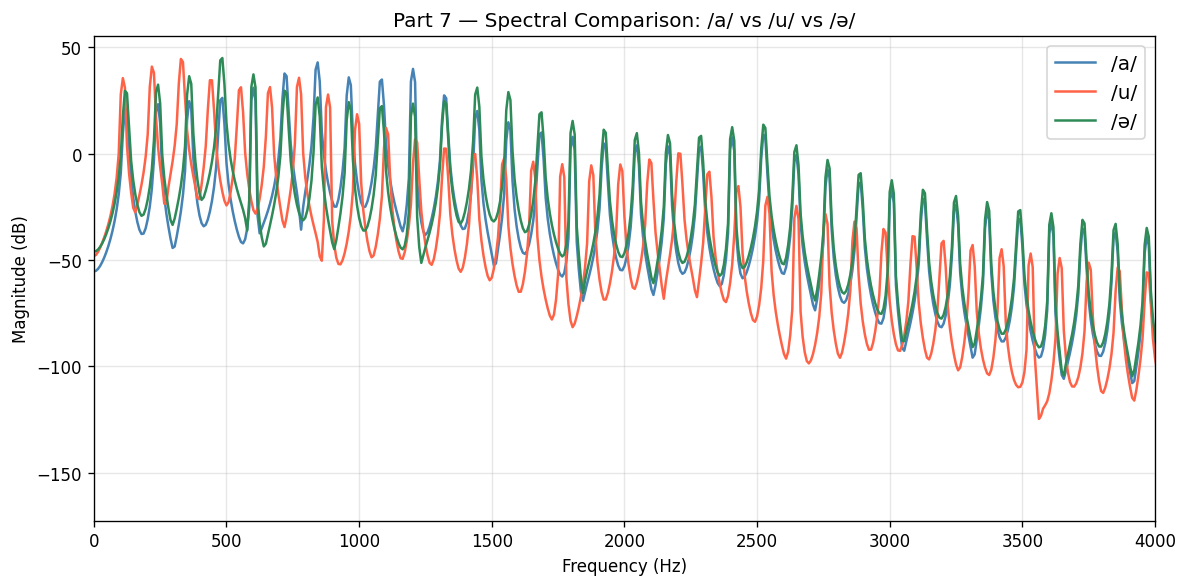

In [10]:
# ── Part 7: Overlay spectra comparison ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("Part 7 — Spectral Comparison: /a/ vs /u/ vs /ə/", fontsize=12)

for (label, (speech, fs)), color in zip(results.items(), colors):
    N      = 2048
    center = len(speech) // 2
    frame  = speech[center:center+N] * np.hanning(N)
    freqs  = np.fft.rfftfreq(N, d=1/fs)
    mag_db = 20 * np.log10(np.abs(np.fft.rfft(frame)) + 1e-10)
    ax.plot(freqs, mag_db, color=color, linewidth=1.5, label=ipa[label])

ax.set_xlim(0, 4000)
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/figures/part7_spectral_overlay.png', bbox_inches='tight')
plt.show()


---
## Export

In [11]:
import shutil
shutil.make_archive('/content/parts6_7_output', 'zip',
                    root_dir='/content', base_dir='synthesis')
shutil.make_archive('/content/parts6_7_figures', 'zip',
                    root_dir='/content', base_dir='figures')

print("=== Synthesis files ===")
for f in sorted(os.listdir('/content/synthesis')): print(f"  {f}")
print("\n=== Figures ===")
for f in sorted(os.listdir('/content/figures')): print(f"  {f}")
print("\n✅ Download parts6_7_output.zip and parts6_7_figures.zip from the Files panel (left sidebar)")


=== Synthesis files ===
  light_crossfaded.wav
  light_raw.wav
  vowel_a_synth.wav
  vowel_schwa_synth.wav
  vowel_u_synth.wav

=== Figures ===
  part6_concatenative_synthesis.png
  part7_spectral_overlay.png
  part7_vowel_synthesis.png

✅ Download parts6_7_output.zip and parts6_7_figures.zip from the Files panel (left sidebar)
